In [2]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

con = sqlite3.connect('C:\\Users\\jasee\\Downloads\\project_3.1\\2_IPL_Cricket\\ipl.db')

def q(sql):
    return pd.read_sql_query(sql, con)

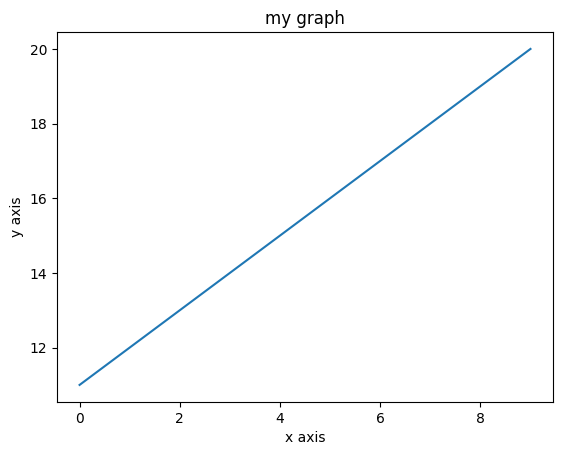

In [5]:
x=[0,1,2,3,4,5,6,7,8,9]
y=[11,12,13,14,15,16,17,18,19,20]
plt.plot(x,y)
plt.title("my graph")
plt.xlabel("x axis")
plt.ylabel("y axis")
plt.show()

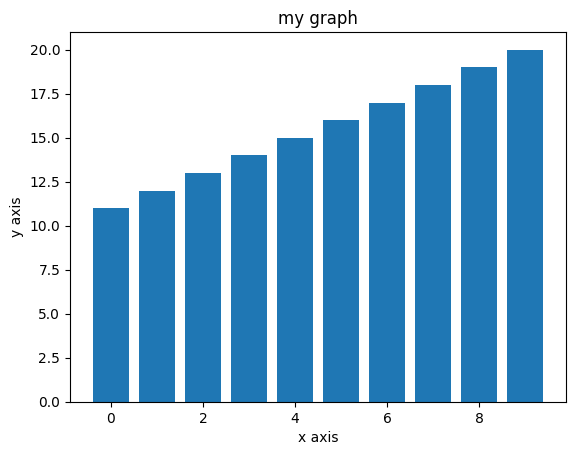

In [4]:
x=[0,1,2,3,4,5,6,7,8,9]
y=[11,12,13,14,15,16,17,18,19,20]
plt.bar(x,y)
plt.title("my graph")
plt.xlabel("x axis")
plt.ylabel("y axis")
plt.show()

<Axes: title={'center': 'total balls in each phase'}, xlabel='diffrent phases of innings', ylabel='total number of balls'>

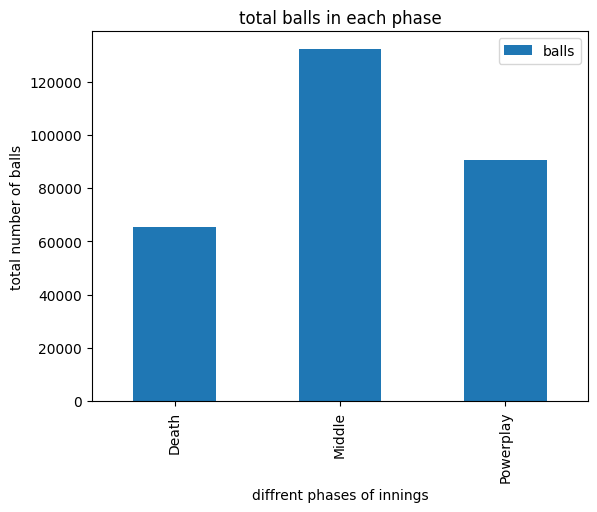

In [9]:
df = pd.read_sql(""" select phase,count(*) as balls from v_ball group by phase;""",con)
df.plot(kind ="bar",
        x="phase",
        y="balls",
        title="total balls in each phase",
        xlabel='diffrent phases of innings',
        ylabel="total number of balls" )

In [10]:
q("""
-- What is the strike rate of every batter in the death overs

SELECT
    batter,
    ROUND(
        100.0 * SUM(batter_runs) /
        SUM(
            CASE
                WHEN is_wide_ball = 0
                 AND is_no_ball = 0
                THEN 1
                ELSE 0
            END
        ),
        2
    ) AS strike_rate
FROM deliveries
WHERE over_number >= 15
  AND is_super_over = 0
GROUP BY batter;
""")



,batter,strike_rate
0,A Ashish Reddy,146.58
1,A Badoni,165.03
2,A Chandila,57.14
3,A Chopra,50.00
4,A Choudhary,125.00
...,...,...
637,Yash Dayal,50.00
638,Yashpal Singh,130.77
639,Yudhvir Singh,166.67
640,Yuvraj Singh,183.40


<Axes: title={'center': 'Strike Rate in Death Overs'}, xlabel='Batters', ylabel='Strike Rate'>

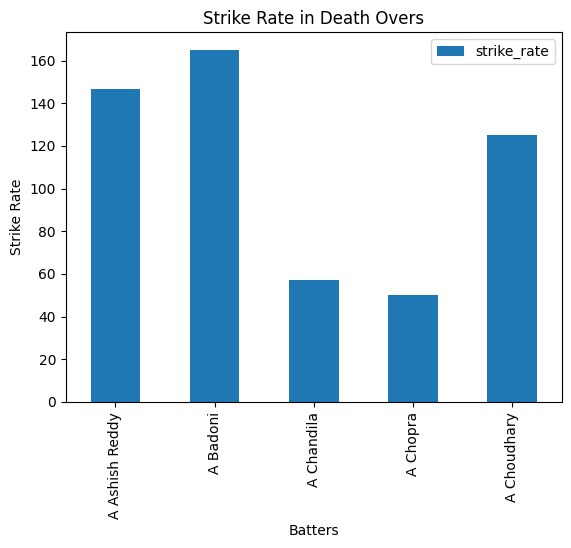

In [17]:
df = pd.read_sql(""" 
SELECT
    batter,
    ROUND(
        100.0 * SUM(batter_runs) /
        SUM(
            CASE
                WHEN is_wide_ball = 0
                 AND is_no_ball = 0
                THEN 1
                ELSE 0
            END
        ),
        2
    ) AS strike_rate
FROM deliveries
WHERE over_number >= 15
  AND is_super_over = 0
GROUP BY batter
limit 5;
""", con)

df.plot(
    kind="bar",
    x="batter",
    y="strike_rate",
    title="Strike Rate in Death Overs",
    xlabel="Batters",
    ylabel="Strike Rate"
)

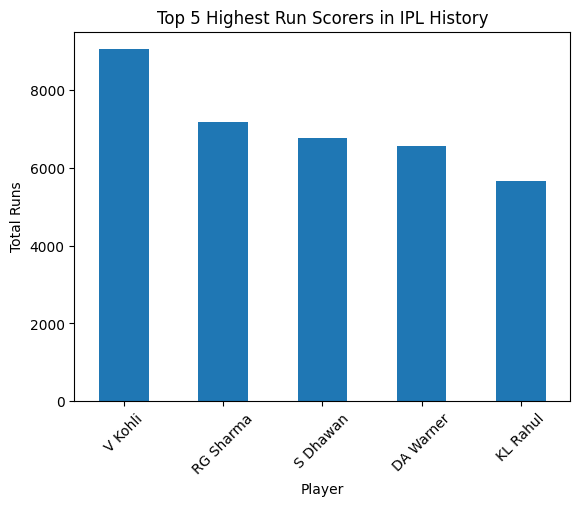

In [13]:
df = q("""
SELECT 
    batter AS player,
    SUM(batter_runs) AS total_runs
FROM v_ball
GROUP BY batter
ORDER BY total_runs DESC
LIMIT 5;
""")

df.plot(
    kind="bar",
    x="player",
    y="total_runs",
    title="Top 5 Highest Run Scorers in IPL History",
    xlabel="Player",
    ylabel="Total Runs",
    legend=False
)

plt.xticks(rotation=45)
plt.show()

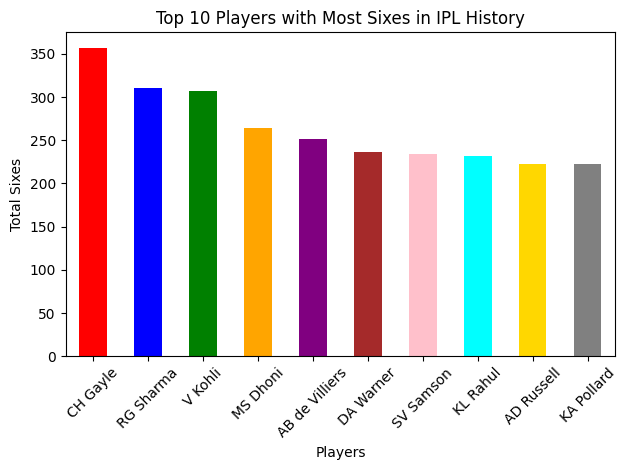

In [27]:


df = q("""
SELECT 
    batter AS player,
    SUM(CASE WHEN batter_runs = 6 THEN 1 ELSE 0 END) AS total_sixes
FROM v_ball
GROUP BY batter
ORDER BY total_sixes DESC
LIMIT 10;
""")

colors = [
    "red", "blue", "green", "orange", "purple",
    "brown", "pink", "cyan", "gold", "gray"
]

df.plot(
    kind="bar",
    x="player",
    y="total_sixes",
    title="Top 10 Players with Most Sixes in IPL History",
    xlabel="Players",
    ylabel="Total Sixes",
    legend=False,
    color=colors
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
q("""
--highest ball faced by a player,total,runs,strike rate

select batter,
            sum(is_legal) as balls,
            sum(batter_runs) as runs,
            round(100.0 * sum(batter_runs) / sum(is_legal), 2) as strike_rate

    from v_ball
    group by batter
    order by balls desc
    limit 10;





""")





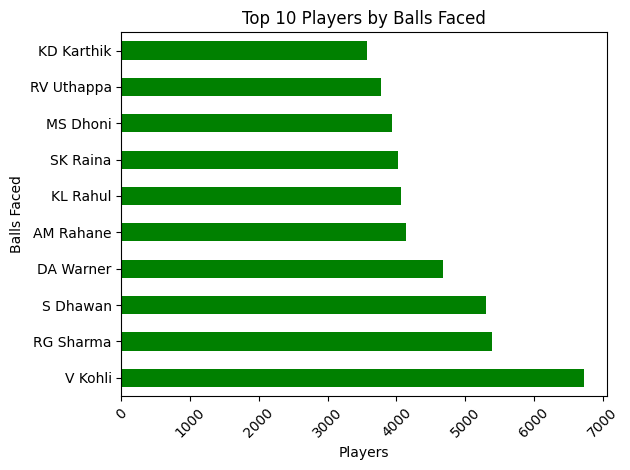

In [28]:


df = q("""
SELECT 
    batter,
    SUM(is_legal) AS balls,
    SUM(batter_runs) AS runs,
    ROUND(100.0 * SUM(batter_runs) / SUM(is_legal), 2) AS strike_rate
FROM v_ball
GROUP BY batter
ORDER BY balls DESC
LIMIT 10;
""")


df.plot(
    kind="barh",
    x="batter",
    y="balls",
    title="Top 10 Players by Balls Faced",
    xlabel="Players",
    ylabel="Balls Faced",
    legend=False,
    color="green"
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

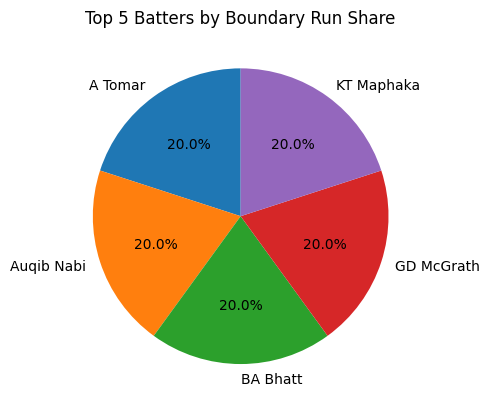

In [32]:


df = q("""
SELECT 
    batter,
    SUM(batter_runs) AS runs,
    ROUND(
        100.0 * SUM(
            CASE 
                WHEN batter_runs IN (4, 6)
                THEN batter_runs
                ELSE 0
            END
        ) / SUM(batter_runs),
        2
    ) AS boundary_perc
FROM v_ball
GROUP BY batter
ORDER BY boundary_perc DESC
LIMIT 5;
""")

plt.pie(
    df["boundary_perc"],
    labels=df["batter"],
    autopct="%1.1f%%",
    startangle=90
)

plt.title("Top 5 Batters by Boundary Run Share")
plt.show()